In [3]:
import pandas as pd 
import os

# Define the dataset path using your absolute file path
dataset_path = r"C:\Users\user\Desktop\Lab_Git_7_Aven\Lab_Git_7_Aven\spotify_top_1000_tracks (1).csv"

# Load Dataset
df = pd.read_csv(dataset_path, encoding="utf-8")

# Convert release_date and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# FIX: We REMOVE the line that tried to create 'duration_min'"spotify_top_1000_tracks (1).csv"
print("✅ Dataset loaded and basic preprocessing complete!")
print(df.head(3))

✅ Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Jynela Bianca G. Aven"
student_id = "TUPM-25-1362"
id_num = int(student_id[-3:]) 


color = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

In [2]:
import pandas as pd
import os
# Define the dataset path using your absolute file path
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"


# Load dataset
df = pd.read_csv(dataset_path, encoding="utf-8")
# Convert release_date and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
# FIX: We REMOVE the line that tried to create 'duration_min'
# because it already exists in the CSV file you loaded.
# (The 'duration_min' column is ready for use!)
print(" Dataset loaded and basic preprocessing complete!")
print(df.head(3))

 Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [4]:
import numpy as np
# Clean up text columns
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()
# Convert 'year' to integer
df['year'] = df['year'].fillna(0).astype(int)

# Drop unnecessary columns
cols_to_drop = ['spotify_url', 'id', 'release_date']
# Check for and add other common audio feature columns if they exist
if 'time_signature' in df.columns:
 cols_to_drop.append('time_signature')
if 'key' in df.columns:
 cols_to_drop.append('key')
if 'mode' in df.columns:
 cols_to_drop.append('mode')
df = df.drop(columns=cols_to_drop, errors='ignore')
# Feature Engineering: Tempo Category
tempo_bins = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']
if 'tempo' in df.columns:
 df['tempo_category'] = pd.cut( # Create tempo category column
 df['tempo'], bins=tempo_bins,
 labels=tempo_labels, right=False
 )
 print("Feature 'tempo_category' created.")
else:
 print("Warning: 'tempo' column not found; skipping 'tempo_category' creation.")
# Remove duplicates
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')
print(f" Data cleaning and feature engineering complete.")
print(f"Final Row Count after deduplication: {len(df)}")

 Data cleaning and feature engineering complete.
Final Row Count after deduplication: 971


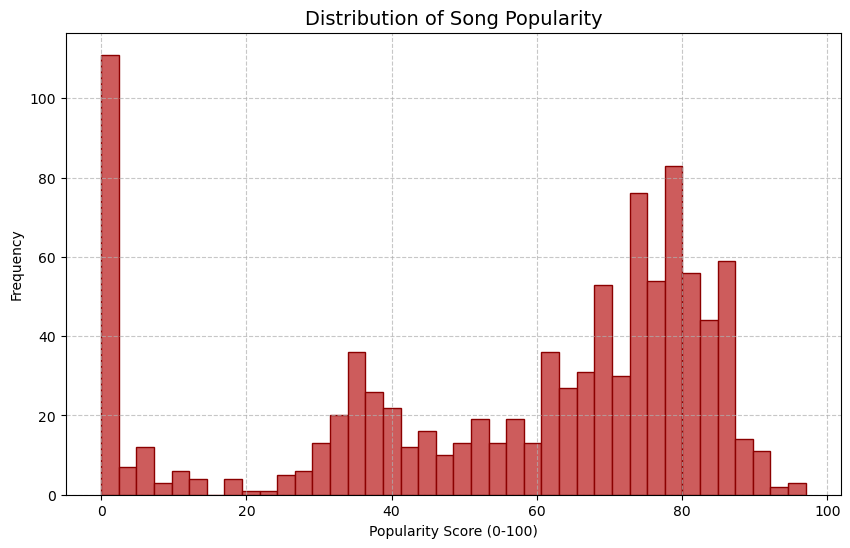

In [5]:
# Histogram
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=40, color='indianred',
edgecolor='darkred')
plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

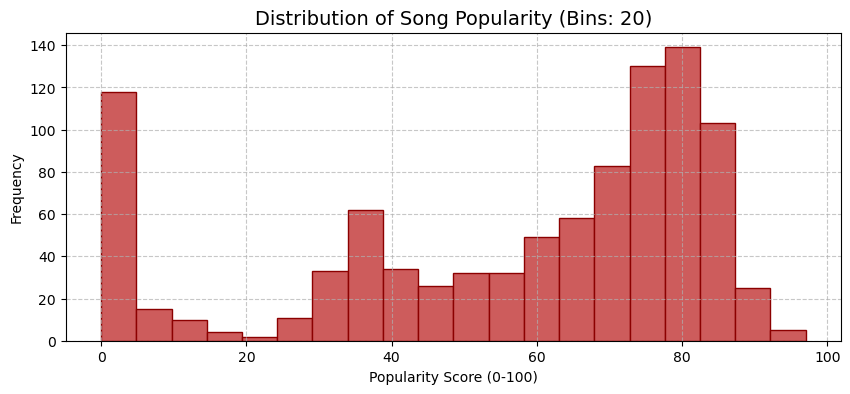

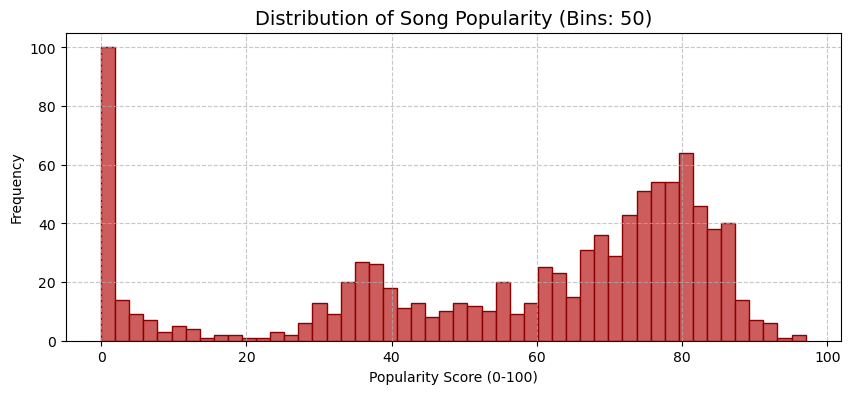

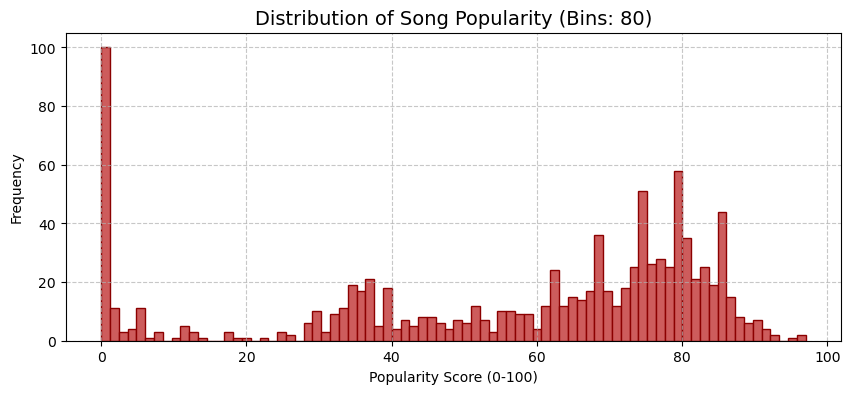

In [6]:
import matplotlib.pyplot as plt

# List of bin counts to test
bin_counts = [20, 50, 80]

for b in bin_counts:
    plt.figure(figsize=(10, 4))
    
    # Using 'popularity' as requested
    plt.hist(df['popularity'], bins=b, color='indianred', edgecolor='darkred')
    
    plt.title(f'Distribution of Song Popularity (Bins: {b})', fontsize=14)
    plt.xlabel('Popularity Score (0-100)')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_46760\4182362457.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


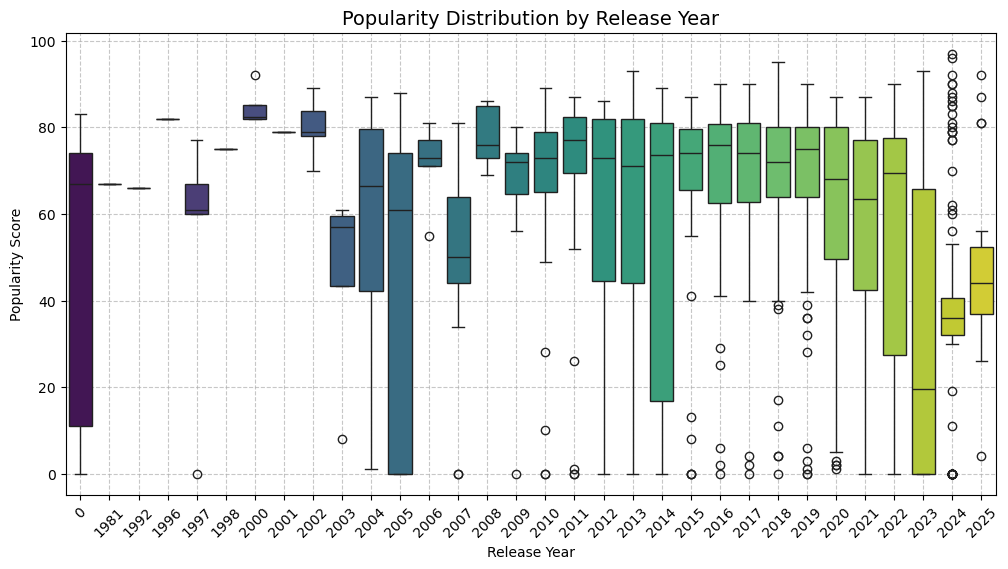

In [ ]:
# Boxplot virdis
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='viridis')
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_46760\3224803652.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='magma')


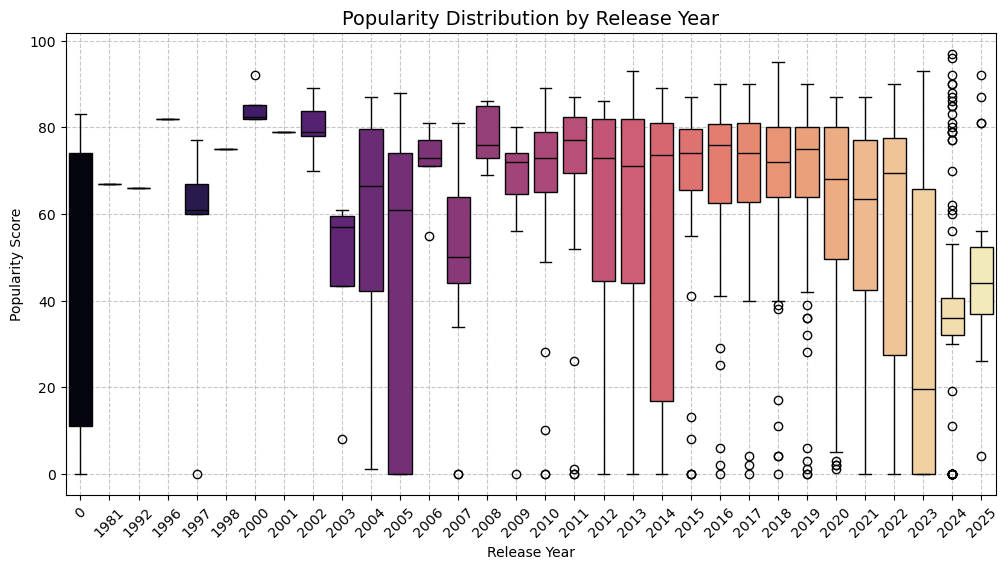

In [ ]:
# Boxplot magma
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='magma')
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_46760\2405226897.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='plasma')


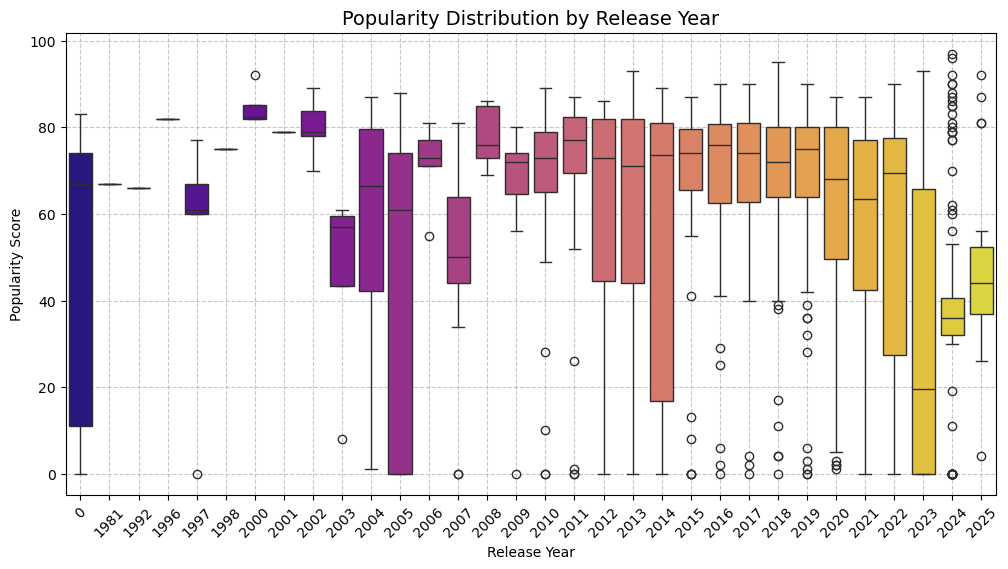

In [ ]:
# Boxplot plasma
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='plasma')
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

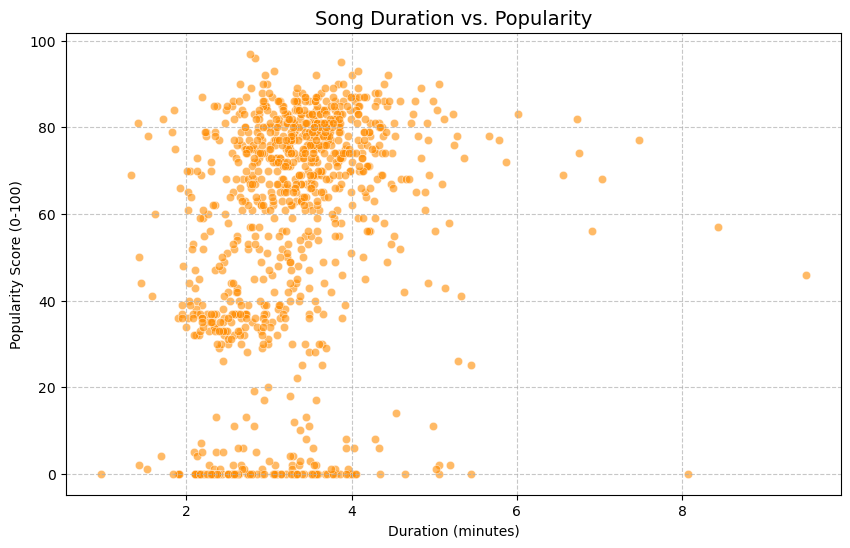

In [11]:
# Scatterplot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6,
color='darkorange')
plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

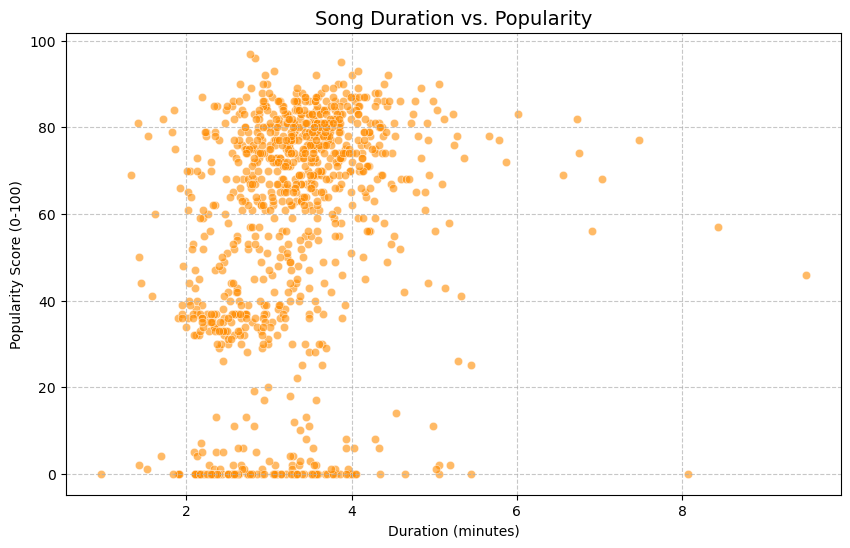

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6,
color='darkorange')
sns.regplot(data=df, x='duration_min', y='popularity', 
line_kws={"color": "red"}, scatter_kws={"alpha": 0.5})
plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

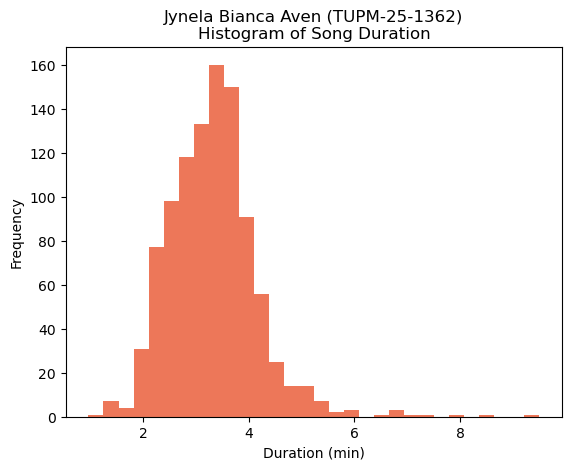

In [7]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

student_name = "Jynela Bianca Aven" 
student_id = "TUPM-25-1362" 
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}" 
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"


# Load dataset
df = pd.read_csv(dataset_path, encoding="utf-8")

df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7) 
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Frequency') 
plt.show()

Success! Renamed 'release_date' to 'release_year'


C:\Users\user\AppData\Local\Temp\ipykernel_29192\1852186011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


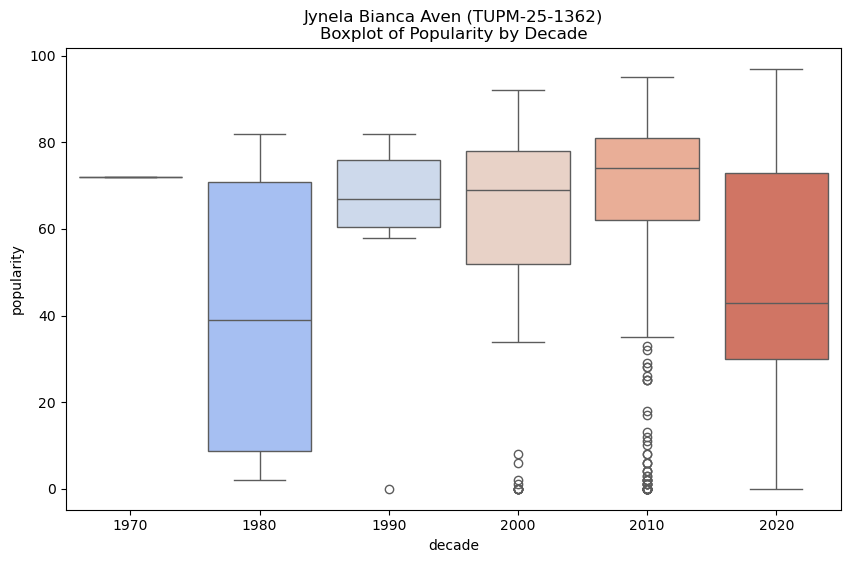

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
id_num = int(student_id[-3:])
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

# 2. Load Data
df = pd.read_csv(dataset_path, encoding="utf-8")

# 3. THE FIX: Automatically find the year column
# We look for any column name containing 'year' or 'date'
potential_year_cols = [c for c in df.columns if 'year' in c.lower() or 'date' in c.lower()]

if potential_year_cols:
    target_col = potential_year_cols[0]
    df.rename(columns={target_col: 'release_year'}, inplace=True)
    print(f"Success! Renamed '{target_col}' to 'release_year'")
else:
    # If we still can't find it, print columns so you can see them
    print("Available columns:", df.columns.tolist())
    raise KeyError("Could not find a year column. Check the list above!")

# 4. Math and Plotting
# Ensure it's numeric (handles cases where the year is '2020' or '2020-01-01')
df['release_year'] = pd.to_numeric(df['release_year'].astype(str).str[:4], errors='coerce')
df = df.dropna(subset=['release_year'])

df['decade'] = (df['release_year'].astype(int) // 10) * 10

plt.figure(figsize=(10, 6))
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_25112\2373169039.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


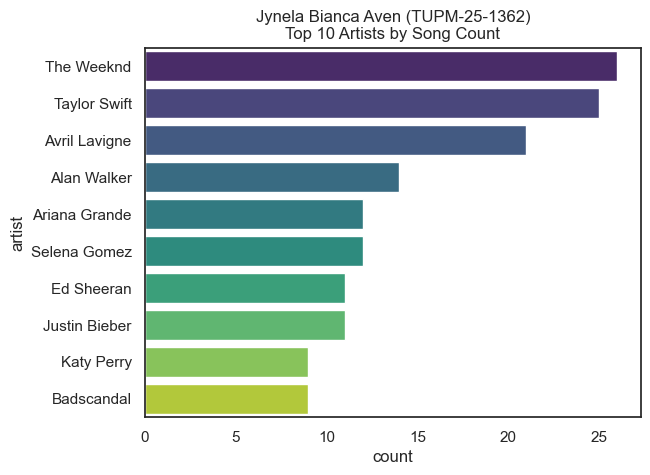

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
id_num = int(student_id[-3:])
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

# 2. Load Data
df = pd.read_csv(dataset_path, encoding="utf-8")



# 2. Load Data
df = pd.read_csv(dataset_path, encoding="utf-8")
sns.countplot(y='artist', data=df, 
order=df['artist'].value_counts().head(10).index, palette='viridis') 
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count") 
plt.show() 



C:\Users\user\AppData\Local\Temp\ipykernel_25112\4240293057.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\user\AppData\Local\Temp\ipykernel_25112\4240293057.py:36: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


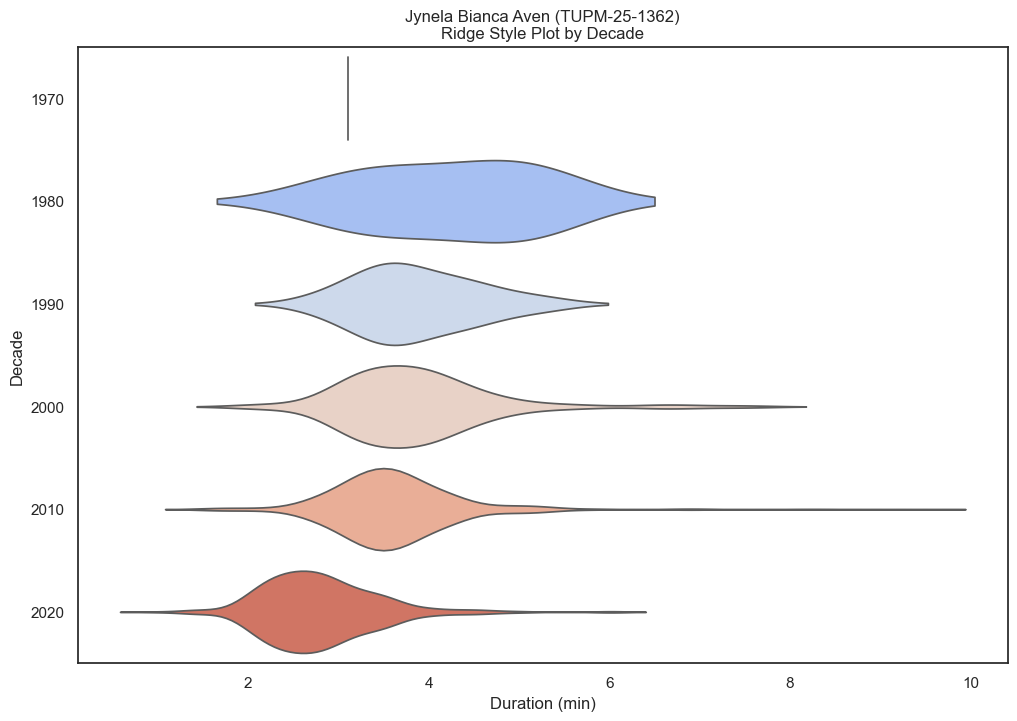

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

# 2. Load Data
df = pd.read_csv(dataset_path, encoding="utf-8")

# --- THE AUTO-FIXER ---
# This finds the column that contains year/date info automatically
potential_cols = [c for c in df.columns if 'year' in c.lower() or 'date' in c.lower()]

if not potential_cols:
    print("Error: Could not find a year column. Your columns are:", df.columns.tolist())
else:
    actual_col_name = potential_cols[0]
    # Extract the year (handles '2024' or '2024-05-01')
    df['clean_year'] = pd.to_numeric(df[actual_col_name].astype(str).str[:4], errors='coerce')
    
    # Calculate decade
    df['decade'] = (df['clean_year'] // 10 * 10).fillna(0).astype(int).astype(str)
    
    # Fix the duration (cleans the X-axis smudge)
    df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce')
    
    # Remove bad data
    df = df.dropna(subset=['duration_min', 'clean_year'])
    df = df[df['clean_year'] > 0].sort_values('decade')

    # 3. Plotting
    plt.figure(figsize=(12, 8))
    sns.violinplot(
        data=df, 
        x='duration_min', 
        y='decade', 
        palette='coolwarm', 
        inner=None, 
        scale='width'
    )

    plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
    plt.xlabel("Duration (min)")
    plt.ylabel("Decade")
    plt.show()

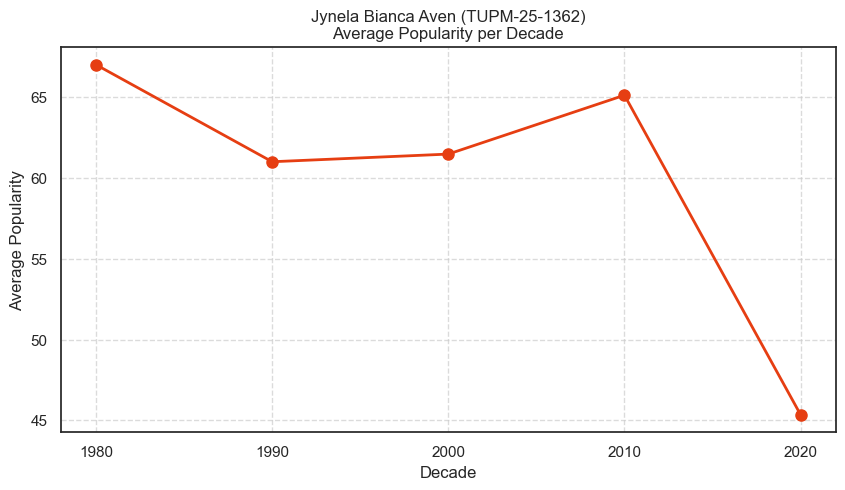

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

# Load df if not already available
if 'df' not in globals():
    df = pd.read_csv(dataset_path, encoding='utf-8')

# Make sure decade exists
if 'decade' not in df.columns:
    if 'year' in df.columns:
        df['decade'] = (pd.to_numeric(df['year'], errors='coerce').astype('Int64') // 10) * 10
    elif 'release_date' in df.columns:
        df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
        df['decade'] = (df['release_date'].dt.year // 10) * 10
    else:
        raise KeyError("No 'year' or 'release_date' column found to compute decade.")

# 2. Group and Calculate
avg_pop = df.groupby('decade')['popularity'].mean().sort_index()

# Define a plot color from the student id
color1 = f"#{(int(student_id[-3:]) * 7) % 256:02x}{(int(student_id[-3:]) * 3) % 256:02x}{(int(student_id[-3:]) * 5) % 256:02x}"

# 3. Plotting
plt.figure(figsize=(10, 5))
avg_pop.plot(kind='line', color=color1, marker='o', linewidth=2, markersize=8)

# 4. Styling
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(avg_pop.index)
plt.show()

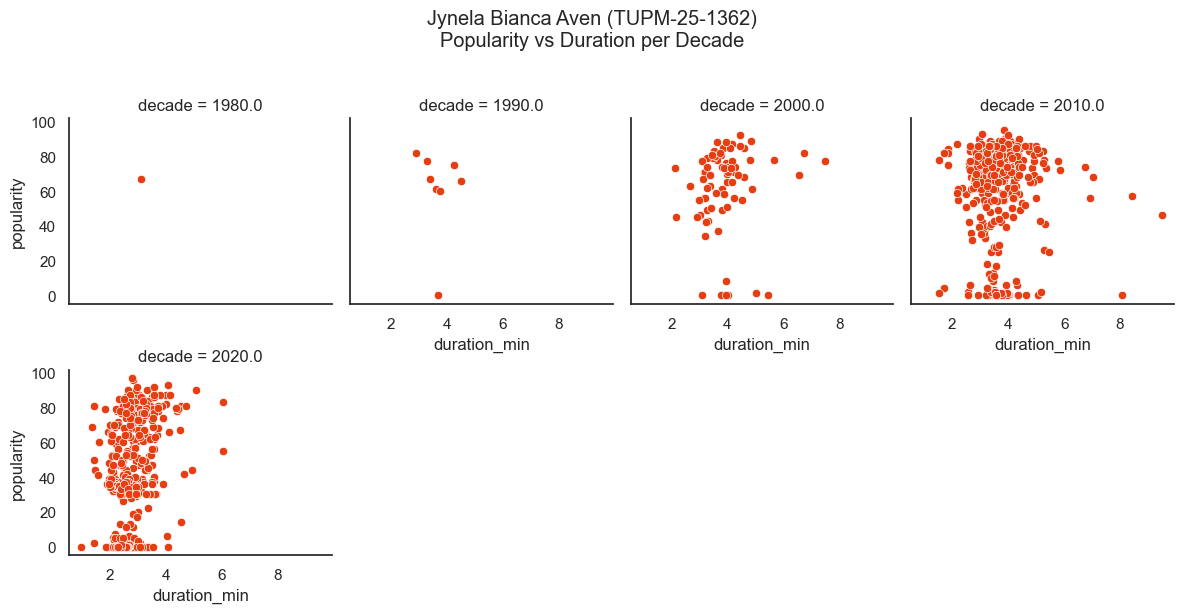

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

df = pd.read_csv(dataset_path, encoding='utf-8')

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['decade'] = (df['release_date'].dt.year // 10) * 10

# Define color1 from student id
color1 = f"#{(int(student_id[-3:]) * 7) % 256:02x}{(int(student_id[-3:]) * 3) % 256:02x}{(int(student_id[-3:]) * 5) % 256:02x}"

g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', color=color1)
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02)
plt.tight_layout()
plt.show()

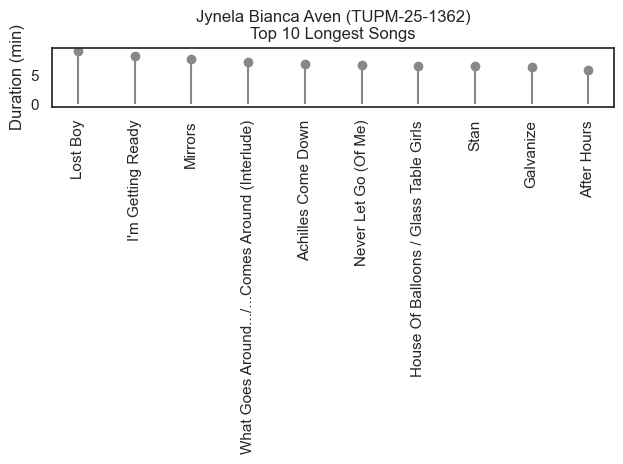

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

df = pd.read_csv(dataset_path, encoding='utf-8')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['decade'] = (df['release_date'].dt.year // 10) * 10

# Top 10 longest tracks
longest = df.nlargest(10, 'duration_min')


plt.stem(longest['track_name'], longest['duration_min'], linefmt='#888888', markerfmt='o', basefmt=' ')
plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()

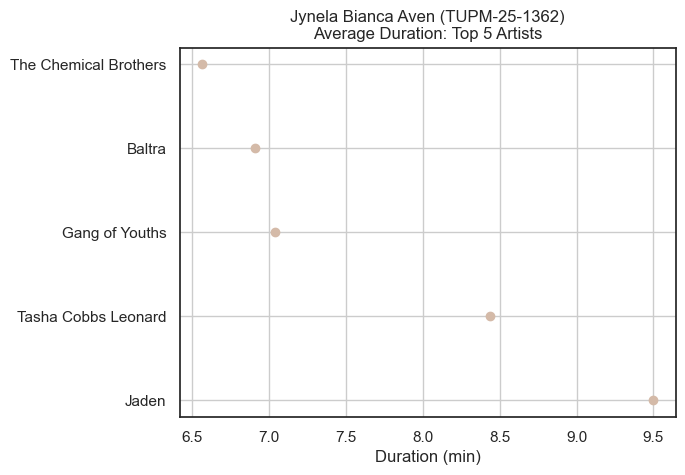

In [37]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

df = pd.read_csv(dataset_path, encoding='utf-8')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['decade'] = (df['release_date'].dt.year // 10) * 10

avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5) 
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2) 
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists") 
plt.xlabel('Duration (min)') 
plt.grid(True) 
plt.show()

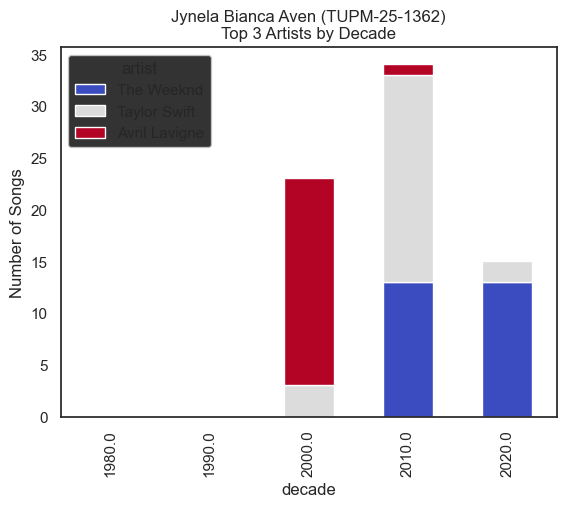

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"


crosstab = pd.crosstab(df['decade'], df['artist']) 
top3 = df['artist'].value_counts().head(3).index 
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm') 
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade") 
plt.ylabel('Number of Songs') 
plt.show() 

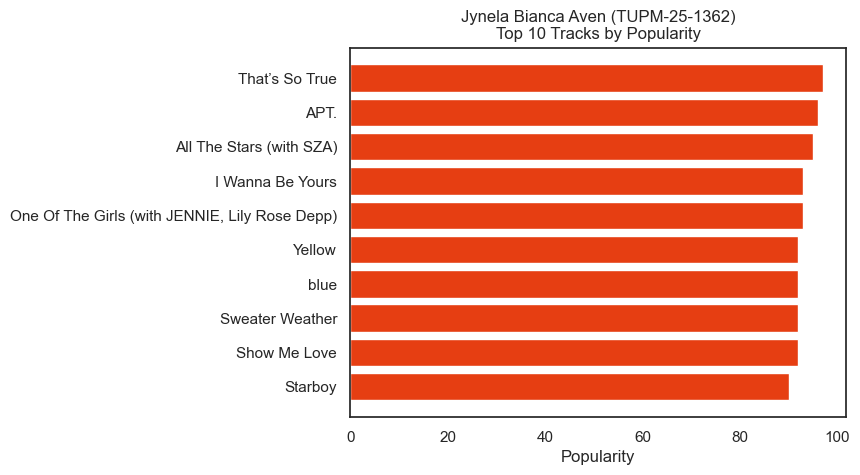

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"




top_tracks = df.nlargest(10, 'popularity') 
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1) 
plt.xlabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity") 
plt.gca().invert_yaxis() 
plt.show() 

C:\Users\user\AppData\Local\Temp\ipykernel_25112\2736910849.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
C:\Users\user\AppData\Local\Temp\ipykernel_25112\2736910849.py:12: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',


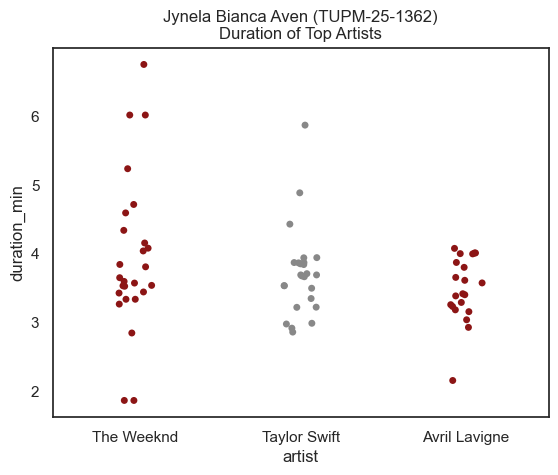

In [43]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"


top_artists = df['artist'].value_counts().head(3).index 
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', 
y='duration_min', palette=['#8C1515', '#888888']) 
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists") 
plt.show() 
plt.show() 

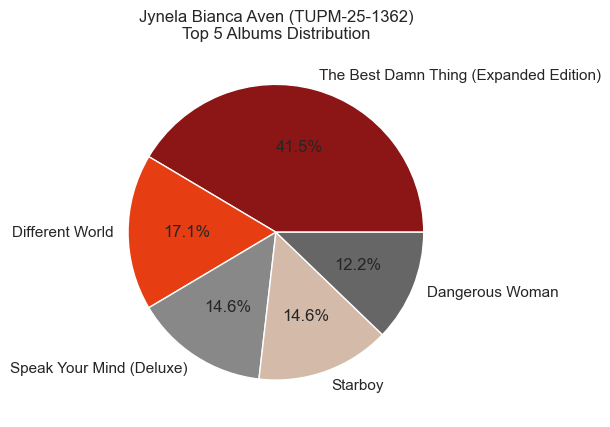

In [46]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

top_albums = df['album'].value_counts().head(5) 
colors = ['#8C1515', color1, '#888888', color2, '#666666'] 
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', 
colors=colors) 
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution") 
plt.show() 

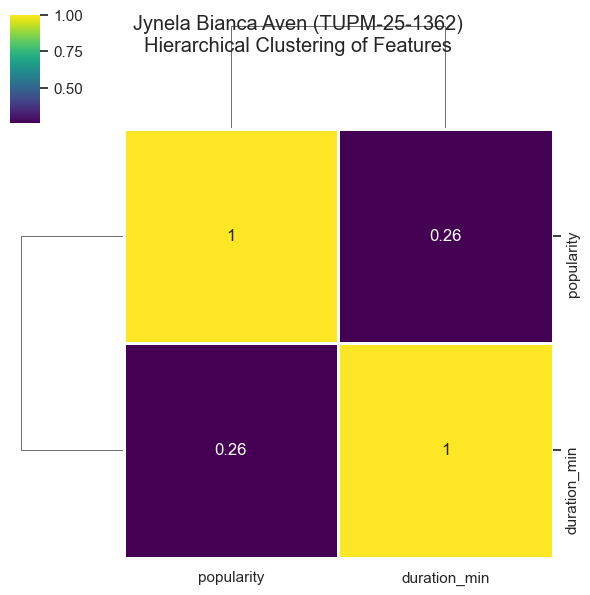

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

numerical_cols = ['popularity', 'duration_min'] 
df_numeric = df[numerical_cols].dropna() 
sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis', 
linewidths=.75, figsize=(6, 6)) 
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features") 
plt.show() 

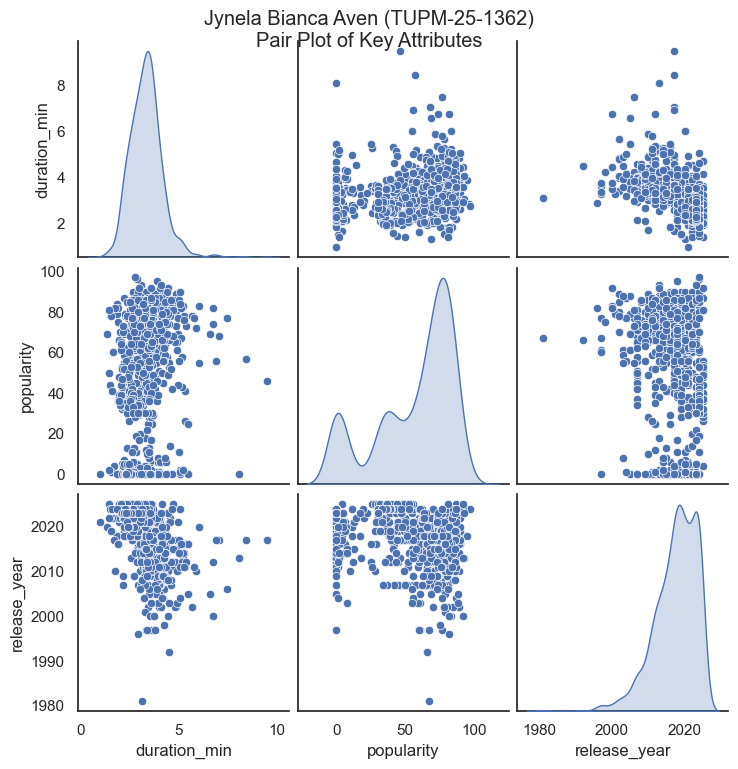

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

df = pd.read_csv(dataset_path, encoding='utf-8')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

sns.pairplot(df[['duration_min', 'popularity', 'release_year']], diag_kind='kde') 
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02) 
plt.show()

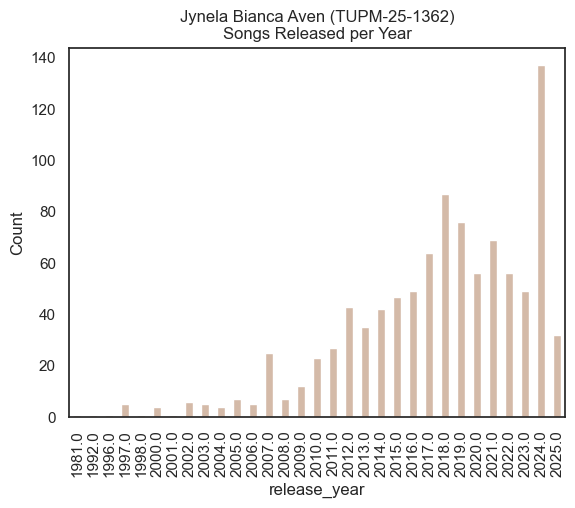

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
id_num = int(student_id[-3:])
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

df = pd.read_csv(dataset_path, encoding='utf-8')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

df['release_year'].value_counts().sort_index().plot(kind='bar', color=color2) 
plt.title(f"{student_name} ({student_id})\nSongs Released per Year") 
plt.ylabel('Count') 
plt.show() 

C:\Users\user\AppData\Local\Temp\ipykernel_25112\3740896496.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')


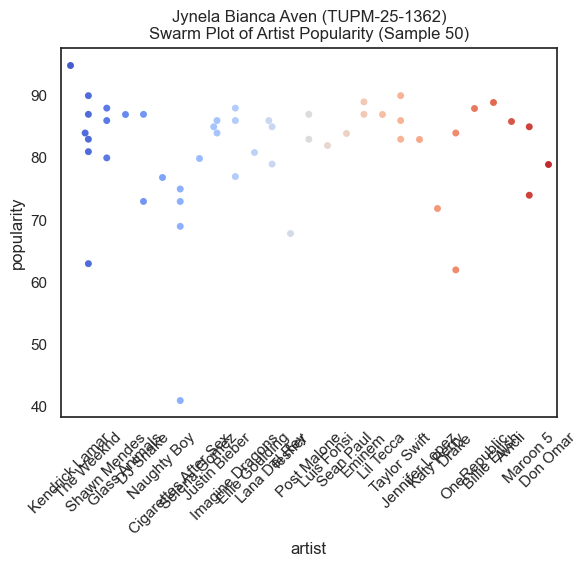

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
id_num = int(student_id[-3:])
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

df = pd.read_csv(dataset_path, encoding='utf-8')


sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm') 
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)") 
plt.xticks(rotation=45) 
plt.show() 

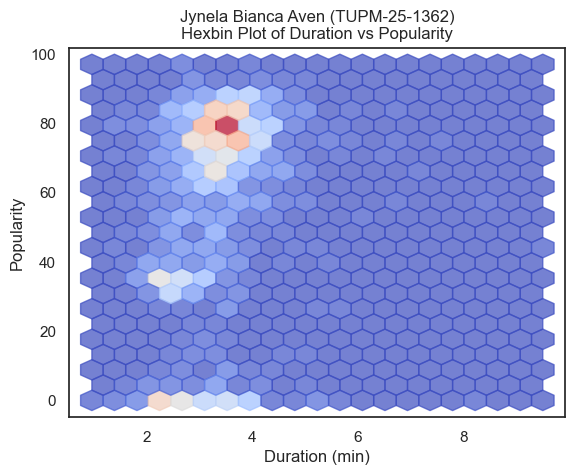

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
id_num = int(student_id[-3:])
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

df = pd.read_csv(dataset_path, encoding='utf-8')

plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, 
cmap='coolwarm', alpha=0.7) 
plt.xlabel('Duration (min)') 
plt.ylabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity") 
plt.show() 

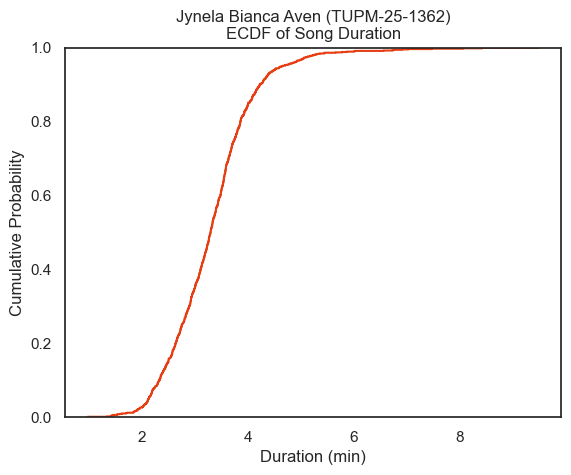

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
id_num = int(student_id[-3:])
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

df = pd.read_csv(dataset_path, encoding='utf-8')


sns.ecdfplot(data=df, x='duration_min', color=color1) 
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Cumulative Probability') 
plt.show() 

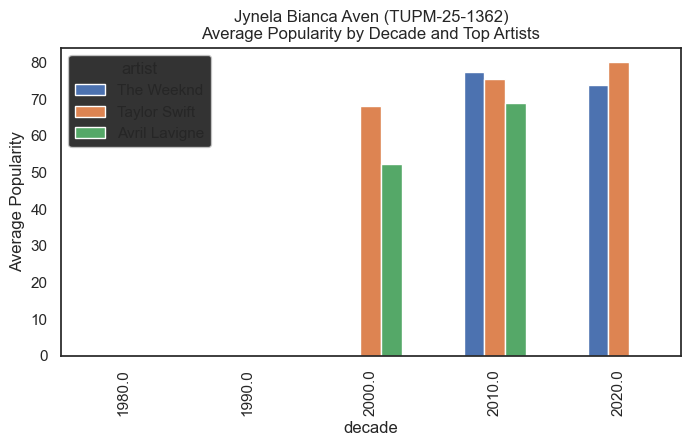

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
id_num = int(student_id[-3:])
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

df = pd.read_csv(dataset_path, encoding='utf-8')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['decade'] = (df['release_date'].dt.year // 10) * 10

top3 = df['artist'].value_counts().head(3).index
avg_artist_decade = df.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4))
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
plt.ylabel('Average Popularity')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
id_num = int(student_id[-3:])


Jynela Bianca Aven (TUPM-25-1362)
TOP 10 LONGEST TRACKS
                                     track_name                artist  duration_min
                                       Lost Boy                 Jaden      9.497883
                              I'm Getting Ready   Tasha Cobbs Leonard      8.436667
                                        Mirrors     Justin Timberlake      8.069100
What Goes Around.../...Comes Around (Interlude)     Justin Timberlake      7.476217
                             Achilles Come Down        Gang of Youths      7.035767
                           Never Let Go (Of Me)                Baltra      6.909833
          House Of Balloons / Glass Table Girls            The Weeknd      6.753550
                                           Stan                Eminem      6.735100
                                      Galvanize The Chemical Brothers      6.563550
                                    After Hours            The Weeknd      6.017100



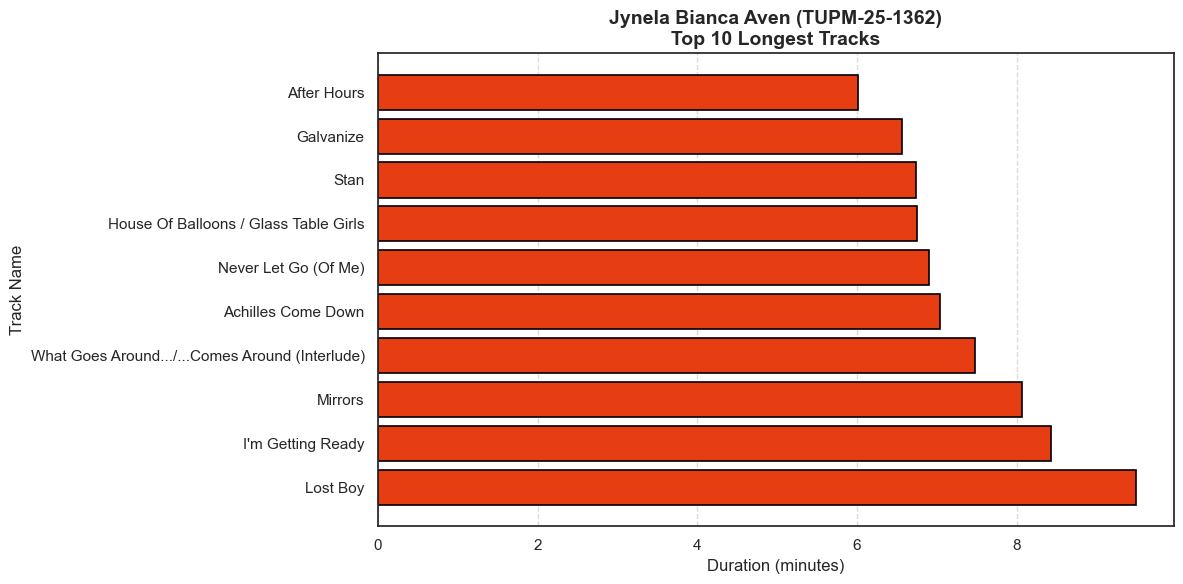

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
id_num = int(student_id[-3:])
color_bar = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

# 2. Load Dataset
df = pd.read_csv(dataset_path, encoding='utf-8')

# 3. Sort by duration_min in descending order and select top 10 longest tracks
top_10_longest = df.nlargest(10, 'duration_min')[['track_name', 'artist', 'duration_min']]

# 4. Display table
print(f"\n{student_name} ({student_id})")
print("=" * 80)
print("TOP 10 LONGEST TRACKS")
print("=" * 80)
print(top_10_longest.to_string(index=False))
print("=" * 80 + "\n")

# 5. Create horizontal bar chart
plt.figure(figsize=(12, 6))
plt.barh(top_10_longest['track_name'], top_10_longest['duration_min'], color=color_bar, edgecolor='black', linewidth=1.2)
plt.xlabel('Duration (minutes)', fontsize=12)
plt.ylabel('Track Name', fontsize=12)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Tracks", fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

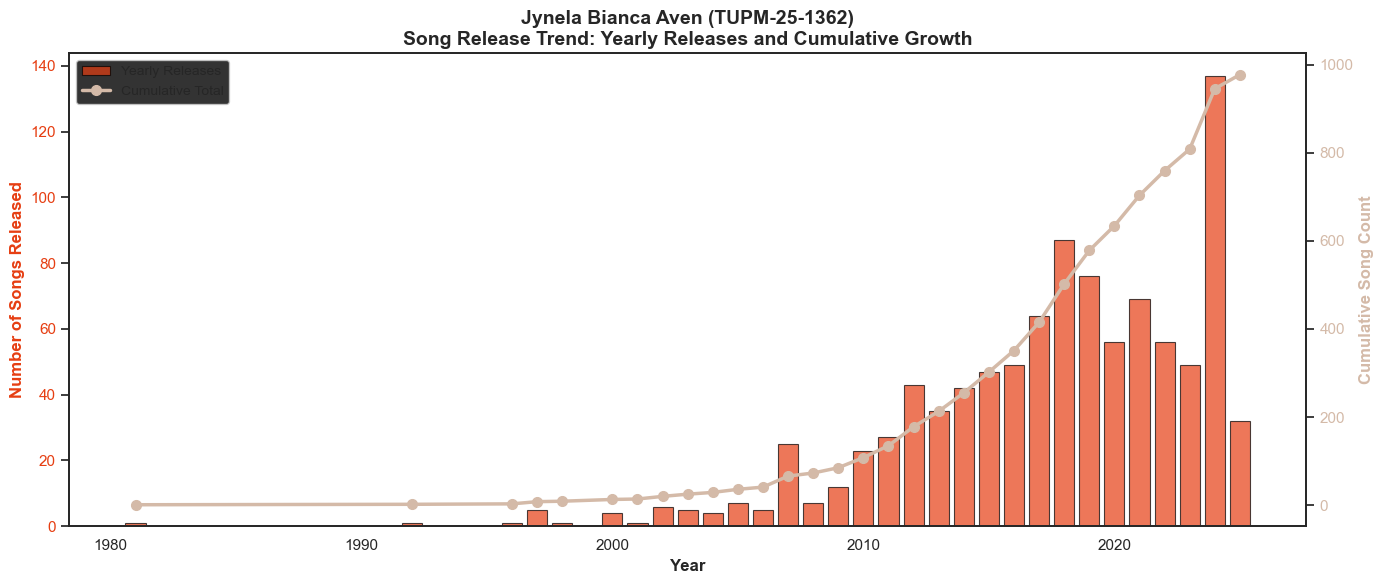

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup & Load
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
id_num = int(student_id[-3:])
color_bar = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color_line = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

# 2. Load Dataset
df = pd.read_csv(dataset_path, encoding='utf-8')

# 3. Extract year from release_date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# 4. Group by year and count songs released
yearly_counts = df['year'].value_counts().sort_index()

# 5. Calculate cumulative song count
cumulative_count = yearly_counts.cumsum()

# 6. Create combined bar + line chart with dual y-axes
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot bars for yearly counts on primary y-axis
ax1.bar(yearly_counts.index, yearly_counts.values, color=color_bar, alpha=0.7, label='Yearly Releases', edgecolor='black', linewidth=0.8)
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Songs Released', fontsize=12, color=color_bar, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_bar)

# Create secondary y-axis for cumulative line
ax2 = ax1.twinx()
ax2.plot(cumulative_count.index, cumulative_count.values, color=color_line, marker='o', linewidth=2.5, markersize=7, label='Cumulative Total')
ax2.set_ylabel('Cumulative Song Count', fontsize=12, color=color_line, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)

# Add title and styling
plt.title(f"{student_name} ({student_id})\nSong Release Trend: Yearly Releases and Cumulative Growth", fontsize=14, fontweight='bold')
fig.tight_layout()

# Add legend combining both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


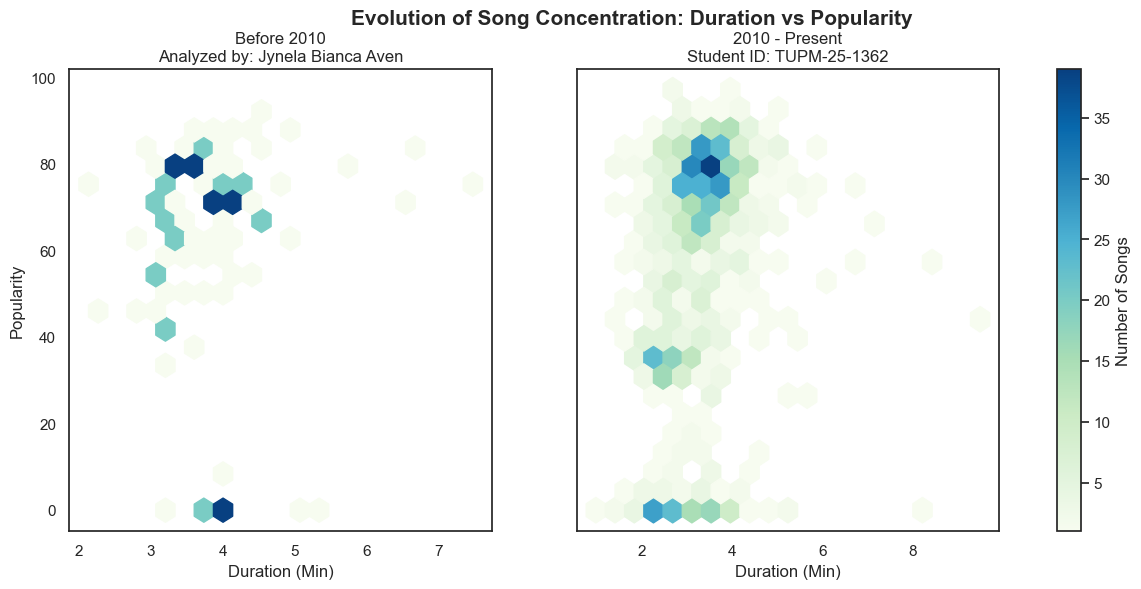

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
cmap_color = "GnBu" # Green-Blue Theme
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

# 2. Load Data
df = pd.read_csv(dataset_path)
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.dropna(subset=['duration_min', 'popularity', 'year'])

# 3. Create a Simple Comparison (Early Years vs Recent Years)
# This shows evolution without needing a moving animation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plot 1: Older Songs (e.g., before 2010)
old_songs = df[df['year'] < 2010]
hb1 = ax1.hexbin(old_songs['duration_min'], old_songs['popularity'], 
                 gridsize=20, cmap=cmap_color, mincnt=1)
ax1.set_title(f"Before 2010\nAnalyzed by: {student_name}")
ax1.set_xlabel("Duration (Min)")
ax1.set_ylabel("Popularity")

# Plot 2: Modern Songs (e.g., 2010 and later)
new_songs = df[df['year'] >= 2010]
hb2 = ax2.hexbin(new_songs['duration_min'], new_songs['popularity'], 
                 gridsize=20, cmap=cmap_color, mincnt=1)
ax2.set_title(f"2010 - Present\nStudent ID: {student_id}")
ax2.set_xlabel("Duration (Min)")

# Add a colorbar to show density
cb = fig.colorbar(hb2, ax=[ax1, ax2], label='Number of Songs')

plt.suptitle(f"Evolution of Song Concentration: Duration vs Popularity", 
             fontsize=15, fontweight='bold')
plt.show()

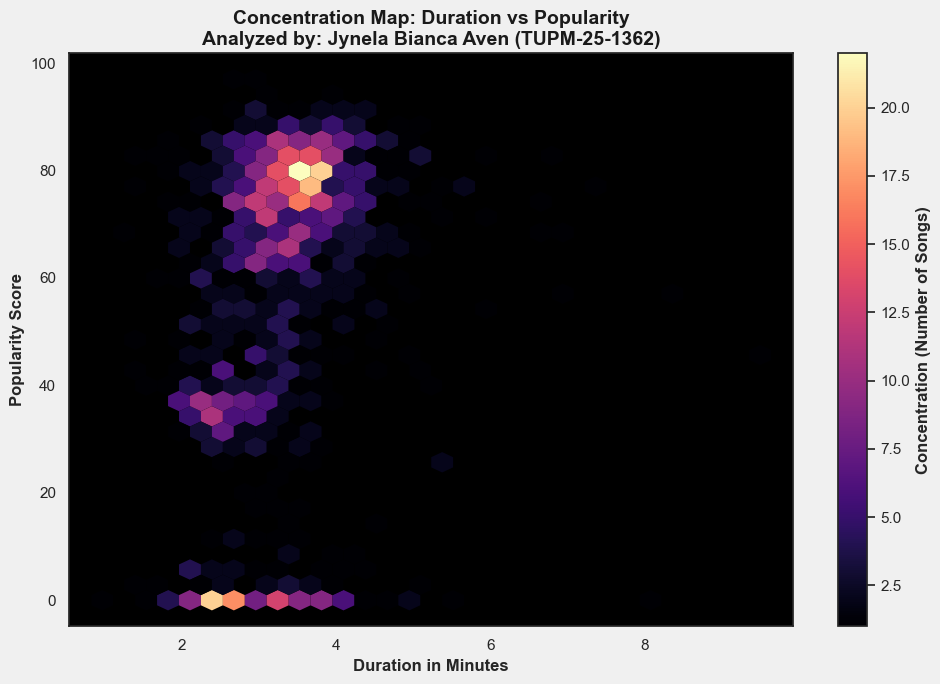

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
# High-contrast palette: 'magma' or 'inferno' are very "strong"
strong_cmap = "magma" 
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

# 2. Load and Prepare Data
df = pd.read_csv(dataset_path)
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.dropna(subset=['duration_min', 'popularity', 'year'])

# 3. Create High-Visibility Map
fig, ax = plt.subplots(figsize=(10, 7), facecolor='#f0f0f0') # Light gray background to make colors pop

# Using a slightly larger gridsize (30) for more detail
hb = ax.hexbin(df['duration_min'], 
               df['popularity'], 
               gridsize=30, 
               cmap=strong_cmap, 
               mincnt=1,
               edgecolors='none') # Removed edgecolors to make the "glow" look stronger

# 4. Customizing for Visibility
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Concentration (Number of Songs)', fontweight='bold')

# Student Personalization in Title
ax.set_title(f"Concentration Map: Duration vs Popularity\nAnalyzed by: {student_name} ({student_id})", 
             fontsize=14, fontweight='bold', color='#1a1a1a')

ax.set_xlabel("Duration in Minutes", fontweight='bold')
ax.set_ylabel("Popularity Score", fontweight='bold')

# Set the plot area background to black to make the 'magma' colors glow
ax.set_facecolor('black')

plt.tight_layout()
plt.show()

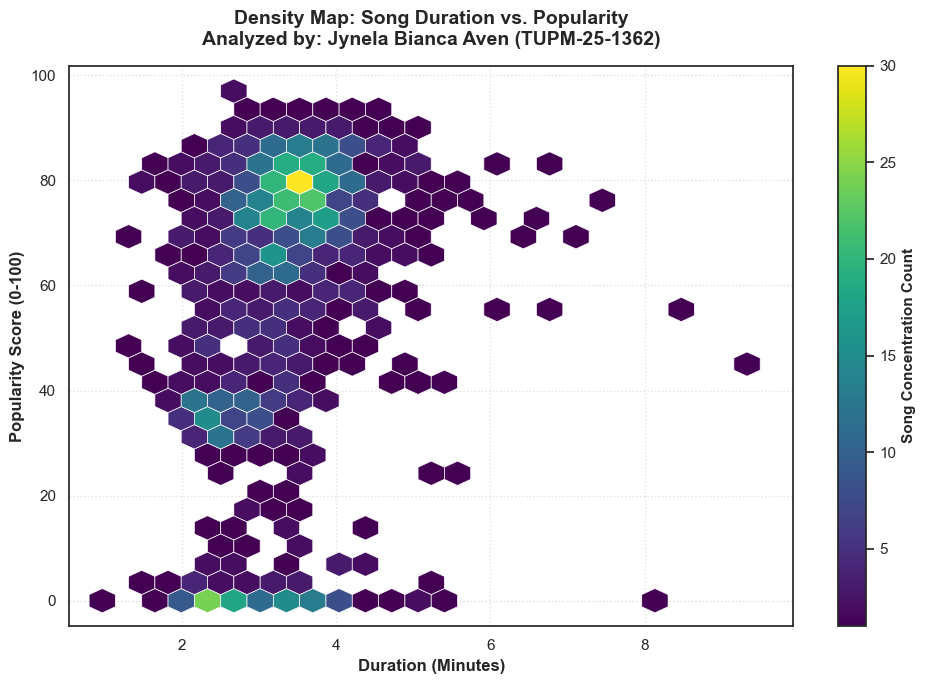

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup & Student Info
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
# 'viridis' is a very strong, professional palette (Purple-Green-Yellow)
# 'plasma' is also great (Purple-Red-Yellow)
strong_cmap = "viridis" 
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

# 2. Load and Prepare Data
df = pd.read_csv(dataset_path)
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.dropna(subset=['duration_min', 'popularity', 'year'])

# 3. Create High-Contrast Map
fig, ax = plt.subplots(figsize=(10, 7))

# gridsize=25: balanced size for clear visibility
# edgecolors='white': creates a "mesh" look that makes the colors pop
hb = ax.hexbin(df['duration_min'], 
               df['popularity'], 
               gridsize=25, 
               cmap=strong_cmap, 
               mincnt=1,
               edgecolors='white', 
               linewidths=0.5)

# 4. Customizing for Visibility
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Song Concentration Count', fontweight='bold', fontsize=11)

# Student Personalization in Title
ax.set_title(f"Density Map: Song Duration vs. Popularity\nAnalyzed by: {student_name} ({student_id})", 
             fontsize=14, fontweight='bold', pad=15)

ax.set_xlabel("Duration (Minutes)", fontweight='bold', fontsize=12)
ax.set_ylabel("Popularity Score (0-100)", fontweight='bold', fontsize=12)

# Adding a light grid for better readability of the axes
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_25112\1852459321.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


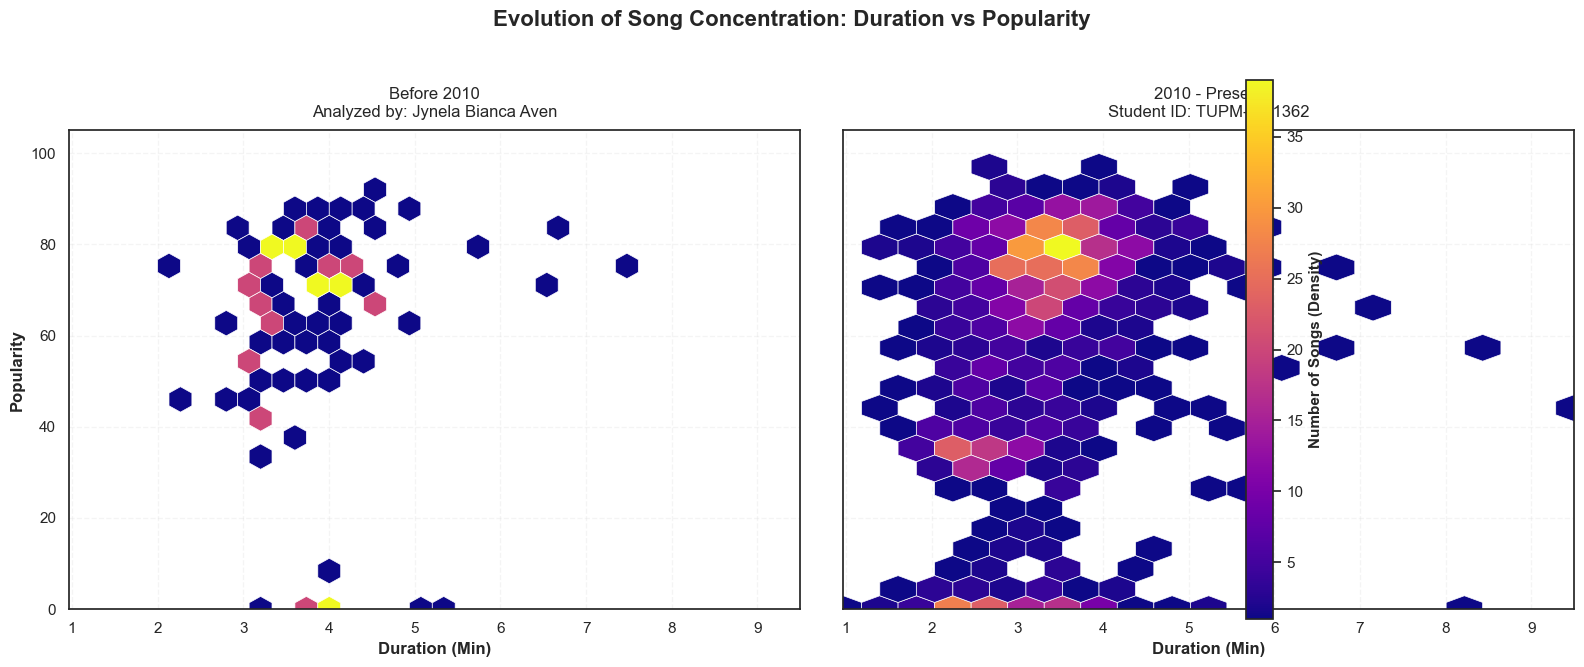

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup & Student Info
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"

bold_cmap = "plasma" 
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

# 2. Load and Prepare Data
df = pd.read_csv(dataset_path)
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.dropna(subset=['duration_min', 'popularity', 'year'])

# 3. Create Side-by-Side Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Define global limits so both plots are perfectly comparable
x_limit = (df['duration_min'].min(), df['duration_min'].max())
y_limit = (0, 105)

# --- PLOT 1: BEFORE 2010 ---
old_songs = df[df['year'] < 2010]
hb1 = ax1.hexbin(old_songs['duration_min'], old_songs['popularity'], 
                 gridsize=20, cmap=bold_cmap, mincnt=1, 
                 edgecolors='white', linewidths=0.5) # White edges make hexagons "pop"

ax1.set_title(f"Before 2010\nAnalyzed by: {student_name}", fontsize=12, pad=10)
ax1.set_xlabel("Duration (Min)", fontweight='bold')
ax1.set_ylabel("Popularity", fontweight='bold')
ax1.set_xlim(x_limit)
ax1.set_ylim(y_limit)

# --- PLOT 2: 2010 - PRESENT ---
new_songs = df[df['year'] >= 2010]
hb2 = ax2.hexbin(new_songs['duration_min'], new_songs['popularity'], 
                 gridsize=20, cmap=bold_cmap, mincnt=1, 
                 edgecolors='white', linewidths=0.5)

ax2.set_title(f"2010 - Present\nStudent ID: {student_id}", fontsize=12, pad=10)
ax2.set_xlabel("Duration (Min)", fontweight='bold')
ax2.set_xlim(x_limit)

# 4. Add a Bold Colorbar
# We use hb2 to define the scale for the colorbar
cb = fig.colorbar(hb2, ax=[ax1, ax2], pad=0.05)
cb.set_label('Number of Songs (Density)', fontweight='bold', fontsize=11)

# 5. Final Styling
plt.suptitle("Evolution of Song Concentration: Duration vs Popularity", 
             fontsize=16, fontweight='bold', y=0.98)

# Add a light grid to the background for readability
ax1.grid(True, linestyle='--', alpha=0.2)
ax2.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

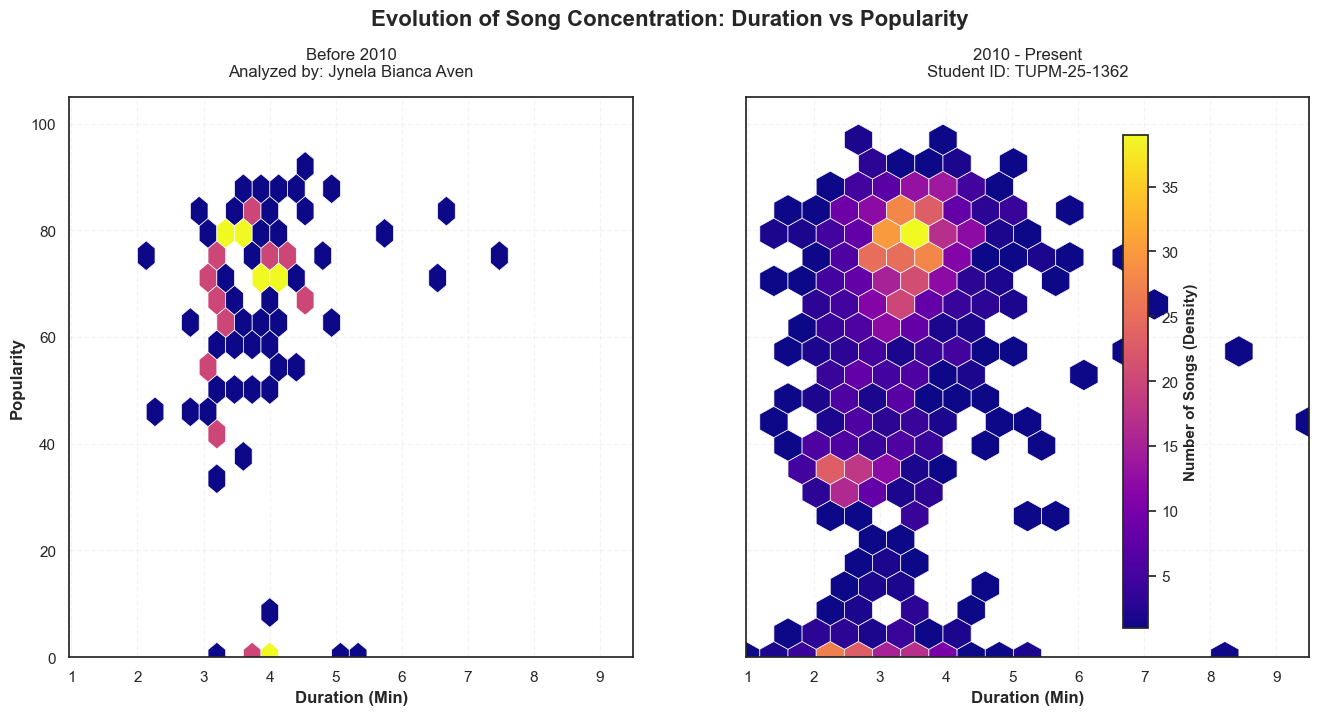

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup & Student Info
student_name = "Jynela Bianca Aven"
student_id = "TUPM-25-1362"
bold_cmap = "plasma" 
dataset_path = r"C:\Users\user\Desktop\Lab7_Git_Aven\Activity 7\spotify_top_1000_tracks (1).csv"

# 2. Load and Prepare Data
df = pd.read_csv(dataset_path)
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.dropna(subset=['duration_min', 'popularity', 'year'])

# 3. Create Side-by-Side Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Define global limits
x_limit = (df['duration_min'].min(), df['duration_min'].max())
y_limit = (0, 105)

# --- PLOT 1: BEFORE 2010 ---
old_songs = df[df['year'] < 2010]
hb1 = ax1.hexbin(old_songs['duration_min'], old_songs['popularity'], 
                 gridsize=20, cmap=bold_cmap, mincnt=1, 
                 edgecolors='white', linewidths=0.5)

ax1.set_title(f"Before 2010\nAnalyzed by: {student_name}", fontsize=12, pad=15)
ax1.set_xlabel("Duration (Min)", fontweight='bold')
ax1.set_ylabel("Popularity", fontweight='bold')
ax1.set_xlim(x_limit)
ax1.set_ylim(y_limit)

# --- PLOT 2: 2010 - PRESENT ---
new_songs = df[df['year'] >= 2010]
hb2 = ax2.hexbin(new_songs['duration_min'], new_songs['popularity'], 
                 gridsize=20, cmap=bold_cmap, mincnt=1, 
                 edgecolors='white', linewidths=0.5)

ax2.set_title(f"2010 - Present\nStudent ID: {student_id}", fontsize=12, pad=15)
ax2.set_xlabel("Duration (Min)", fontweight='bold')
ax2.set_xlim(x_limit)

# 4. Add a Bold Colorbar (Spacing fix: pad and shrink)
cb = fig.colorbar(hb2, ax=[ax1, ax2], pad=0.08, shrink=0.8)
cb.set_label('Number of Songs (Density)', fontweight='bold', fontsize=11)

# 5. Final Styling & Overlap Fix
plt.suptitle("Evolution of Song Concentration: Duration vs Popularity", 
             fontsize=16, fontweight='bold', y=0.96)

# Add a light grid
ax1.grid(True, linestyle='--', alpha=0.2)
ax2.grid(True, linestyle='--', alpha=0.2)

# Subplots adjust is used INSTEAD of tight_layout to prevent title overlap
plt.subplots_adjust(top=0.85, bottom=0.15, wspace=0.2)

plt.show()